***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [1. 利用干涉阵开展射电科学](1_0_introduction.ipynb)
    * 上一节： [1.10 单碟天文学的局限](1_10_limits_of_single_dishes.ipynb)
    * 下一节： [1.12 延伸阅读与参考文献](1_x_further_reading_and_references.ipynb)

***


导入标准模块:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML 
HTML('../style/course.css') #apply general CSS

导入本节所需的专用模块:

In [3]:
import matplotlib.image as mpimg
from IPython.display import Image

In [3]:
HTML('../style/code_toggle.html')

## 1.11 现代射电干涉阵

现代射电干涉阵很容易被误解为一张设施名单：记住几个著名阵列的名字、口径和所在国家，似乎就算掌握了这一节。但真正重要的不是背设施参数，而是理解为什么会有这么多不同类型的阵列，以及这些阵列各自解决了什么科学问题。换句话说，本节的核心任务不是做设备百科，而是建立一种**由科学目标反推阵列设计**的视角。

现代射电干涉阵的差异，主要体现在观测频率范围、阵元类型、视场、最长与最短基线、频谱与时间分辨率、偏振能力、数据率以及校准复杂度上。理解这些差异之后，ALMA 和 LOFAR 看起来像来自两个世界就不再奇怪；ASKAP 强调巡天速度、VLBI 强调时间与几何精度、SKA 把硬件和软件视为同等重要的系统组成部分，也都会变成科学需求推动下的自然结果。


### 1.11.1 不是所有干涉阵都在解决同一个问题

不同阵列之间的区别，并不只是“谁更大、谁更灵敏”。每一台阵列都是围绕某类科学需求做出的工程取舍。高动态范围通用成像需要较好的 $uv$ 覆盖、稳定的天线波束和成熟的校准链条；大面积巡天更重视视场、波束数和巡天速度；低频观测必须面对电离层、宽场成像和方向依赖效应；毫米和亚毫米干涉则把大气水汽、天线表面精度与相位稳定性推到设计核心；极限角分辨率则要求把阵列尺度推进到大陆甚至地球尺度。

因此，阅读现代阵列时应始终追问两个问题：这台阵列最擅长哪类科学问题？它的设计是如何服务这些问题的？如果这两个问题回答清楚，设施参数就不再是孤立数字，而会成为科学目标、硬件选择和算法流程之间的连接点。


In [ ]:
Image(filename='figures/array_design_tradeoffs.png', width=900)

**图 1.11.1**：现代射电阵列的设计压力示意。不同阵列家族并不是沿同一条“性能排行榜”排列，而是面对不同频率窗口、视场、空间尺度、校准和计算需求所形成的不同解。


### 1.11.2 通用型中频碟阵：从工程先导到高性能成像

碟形天线阵列仍然是现代射电干涉测量中最典型、也最容易与经典“望远镜”直觉对应的一类系统。它们通常工作在 cm 波到 dm 波段，适合做连续谱、偏振和谱线的综合观测。对教学而言，这类阵列最重要，因为后续许多成像、波束、标定和 RIME 的讨论，首先都可以在碟阵框架下理解。

KAT-7 这类先导阵列的重要意义，不只是“比前人多几面天线”，而是为后续更大系统验证阵元设计、后端系统、相关器与观测流程。紧凑小阵列虽然分辨率和 $uv$ 覆盖有限，但非常适合承担工程验证与方法开发任务。


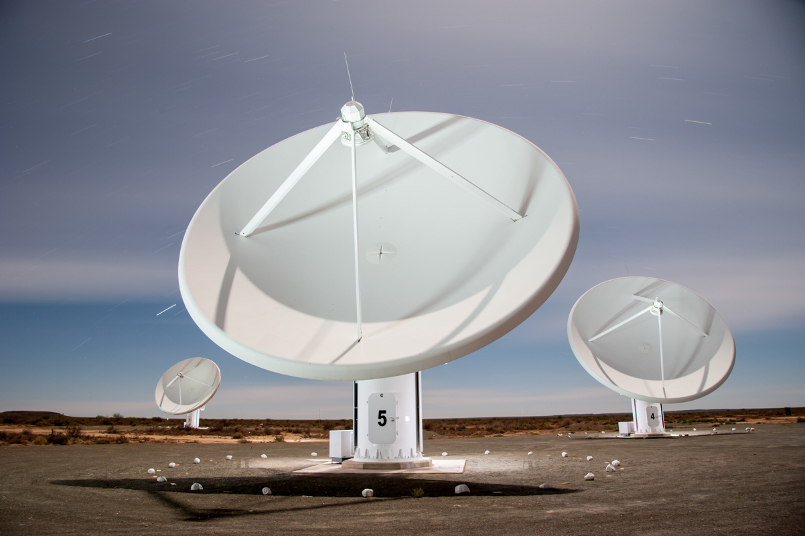

In [4]:
Image(filename='figures/arrays/kat7_dish_2013.jpg')

**图 1.11.2**：KAT-7 主焦望远镜。图片来源： [SARAO&#10548;](https://www.sarao.ac.za/wp-content/uploads/2016/06/2013_kat7_04-1030x686.jpg)


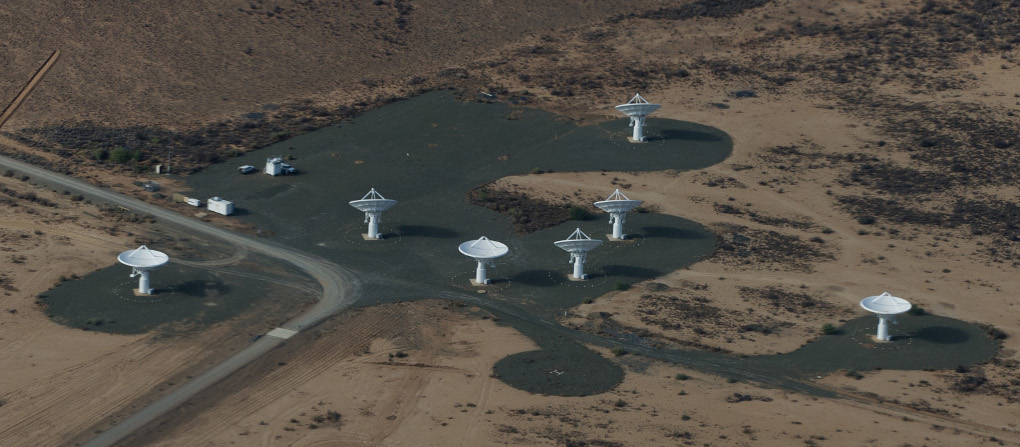

In [5]:
Image(filename='figures/arrays/kat7_2016_aerial.jpg')

**图 1.11.3**：位于南非北开普的 KAT-7 阵列布局。图片来源： [SARAO&#10548;](https://www.sarao.ac.za/wp-content/uploads/2016/06/2013_kat7_04-1030x686.jpg)


MeerKAT 代表了通用型中频碟阵向高灵敏度、高动态范围和高质量成像推进的方向。它保留了碟阵在主波束、带宽、频谱和偏振方面的通用性，同时通过更多阵元、更长基线和更成熟的系统设计，显著增强了深场成像、H I 研究、脉冲星与暂现源工作的能力。MeerKAT 也是理解“阵列布局如何影响成像质量”的典型实例：致密核心提升对大尺度结构的敏感性，向外延伸的基线提供更高分辨率，两者共同决定图像可以同时包含多少低面亮度结构和精细结构。


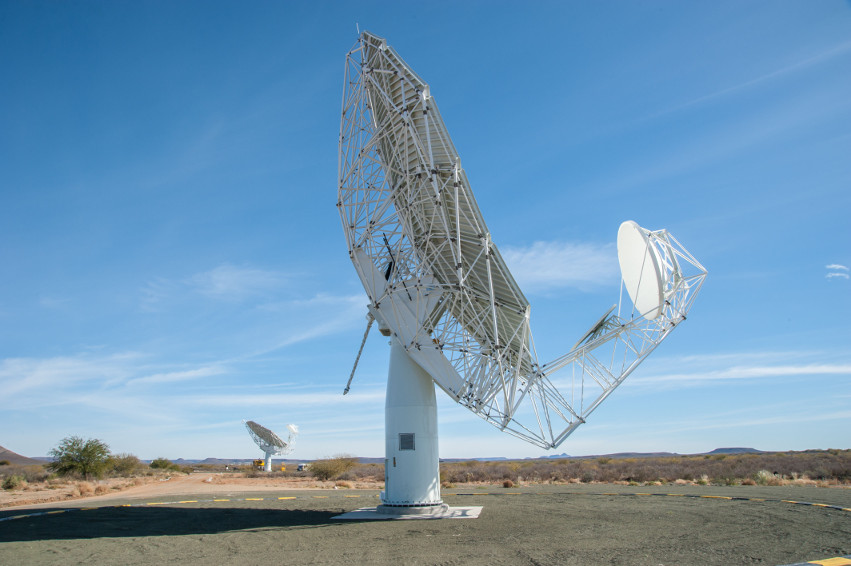

In [6]:
Image(filename='figures/arrays/meerkat_dish_2015.jpg')

**图 1.11.4**：MeerKAT 偏轴格里高利天线，图中尚未安装馈源系统。图片来源： [SARAO&#10548;](https://www.sarao.ac.za/wp-content/uploads/2016/06/2015_meerkat_03-1030x685.jpg)


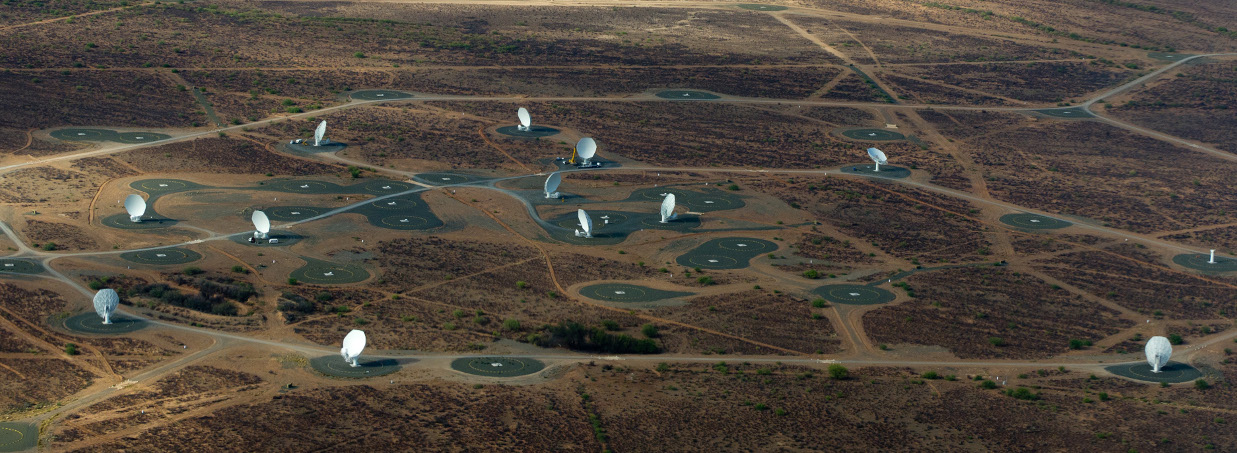

In [7]:
Image(filename='figures/arrays/meerkat_2016_aerial.jpg')

**图 1.11.5**：位于南非北开普的 MeerKAT 阵列核心布局。图片来源： [SARAO&#10548;](https://www.sarao.ac.za/wp-content/uploads/2018/04/2017_aerial_02-1030x579.jpg)


JVLA 则是另一种典型思路。它通过可重构阵列，把“角分辨率”和“最大可恢复尺度”之间的权衡显式交给观测者。A、B、C、D 构型并不是简单的口径变化，而是在提醒我们：**没有一种阵列布局能同时对所有空间尺度都最优。** 在真实项目中，是否需要多构型联合成像、是否需要单碟补充、以及成像时选择何种权重，都与这一点直接相关。


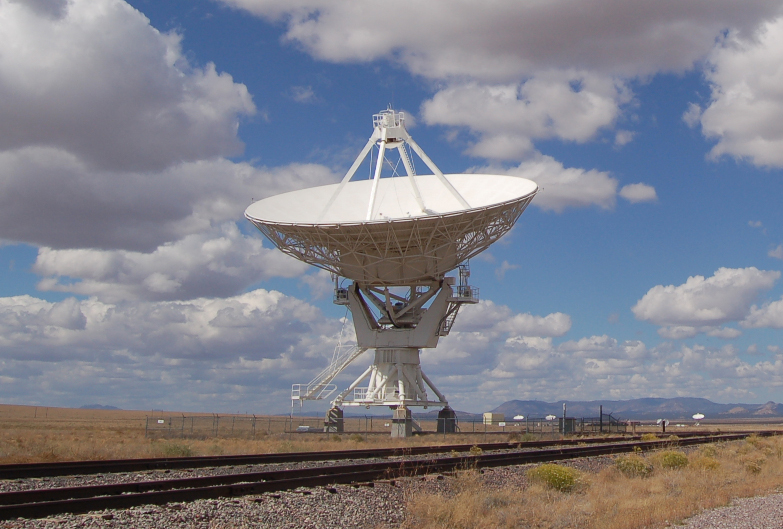

In [8]:
Image(filename='figures/arrays/vla_dish_2007.jpg')

**图 1.11.6**：JVLA 卡塞格林焦点天线，前景中的轨道用于把天线移动到不同位置。图片来源： [维基共享资源&#10548;](https://en.wikipedia.org/wiki/File:Very_large_array_clouds.jpg)


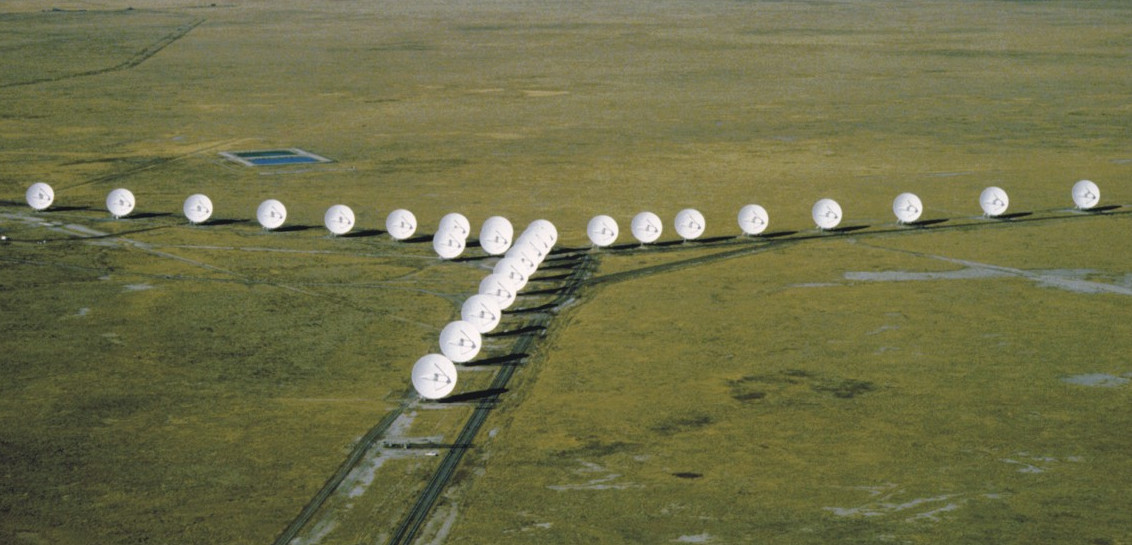

In [9]:
Image(filename='figures/arrays/vla_aerial.jpg')

**图 1.11.7**：JVLA 在最致密 D 构型下的阵列布局。图片来源： [NRAO/AUI&#10548;](http://images.nrao.edu/Telescopes/VLA/307)


通用型碟阵提供的不是某一台设施的参数记忆，而是一套方法论。单面天线尺寸决定主波束与单天线视场，基线分布决定空间频率采样和尺度响应，宽带、偏振和多构型能力决定阵列是否适合做综合性科学项目。正因为这类阵列的波束、接收机、相关器和校准流程相对成熟，它们也常成为数据处理软件、成像算法和校准方法最重要的试验场。


### 1.11.3 巡天优化阵列：大视场与多波束

并不是所有阵列都把“单个天区做到最好”作为第一目标。有些项目更关心在有限总时间内覆盖尽可能大的天空面积，这就把巡天速度推到设计核心。ASKAP 是这一思路的代表，它的关键不是最长基线有多长，而是通过相控阵馈源（PAF）在焦平面形成多束，从而显著扩大有效视场。


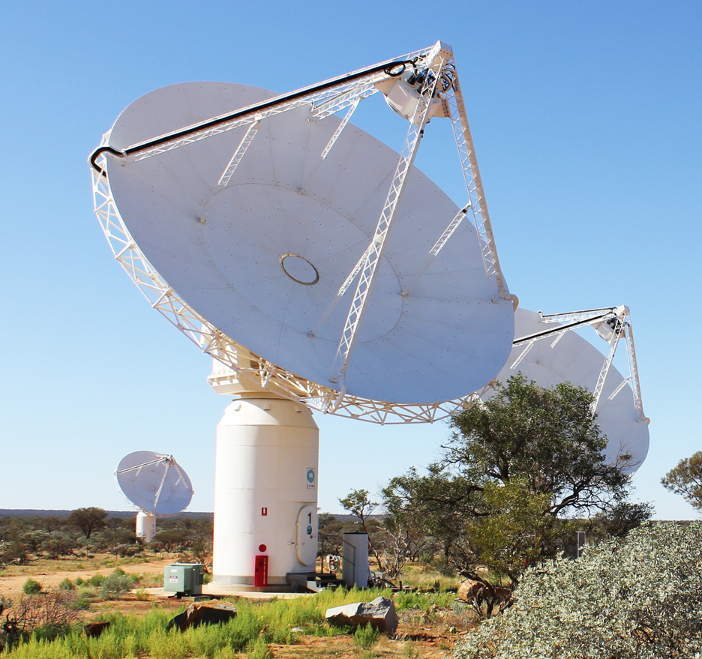

In [10]:
Image(filename='figures/arrays/askap_dish_2015.jpg')

**图 1.11.8**：ASKAP 配备相控阵馈源的天线。图片来源： [CSIRO&#10548;](https://www.skatelescope.org/wp-content/uploads/2015/12/ASKAP_MkI_MkII1.jpg)


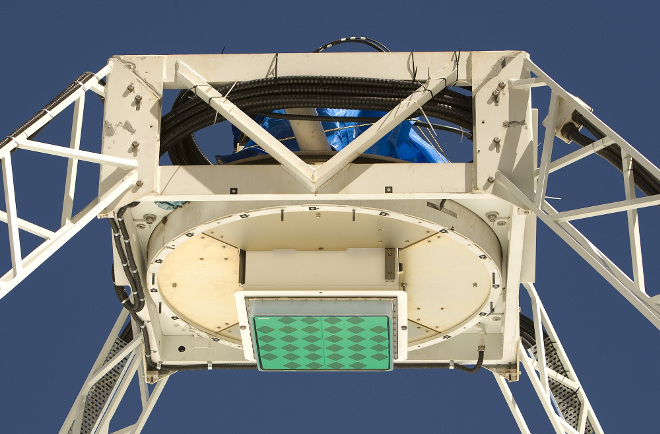

In [11]:
Image(filename='figures/arrays/askap_paf_2010.jpg')

**图 1.11.9**：ASKAP 上的第一代相控阵馈源近景。图片来源： [CSIRO/David McClenaghan&#10548;](http://www.scienceimage.csiro.au/image/11278/csiro-s-prototype-phased-array-feed-in-position-on-an-antenna-for-testing/)


PAF 带来的好处，是在保持碟阵干涉能力的同时提高巡天效率；带来的代价，则是主波束模型、波束间一致性和方向依赖校准都会更复杂。也就是说，ASKAP 这类阵列让我们看到：现代射电望远镜的竞争力不只来自机械结构，还来自阵元后端电子学和数字波束形成能力。对后续学习而言，它提醒我们不要把“主波束”想象成一个永远简单、固定的二维函数。


### 1.11.4 低频孔径阵：当阵元不再是碟形天线

低频端的设计思路与中频碟阵差别很大。像 LOFAR 这样的系统并不依赖单面反射面，而是把大量简单偶极子组合成台站，在台站内部先做波束形成，再把各台站送入相关器。这样的设计在低频尤其有吸引力，因为此时天空温度高、波长长，使用简单阵元和电子转向比建造大量可动碟天线更合理。


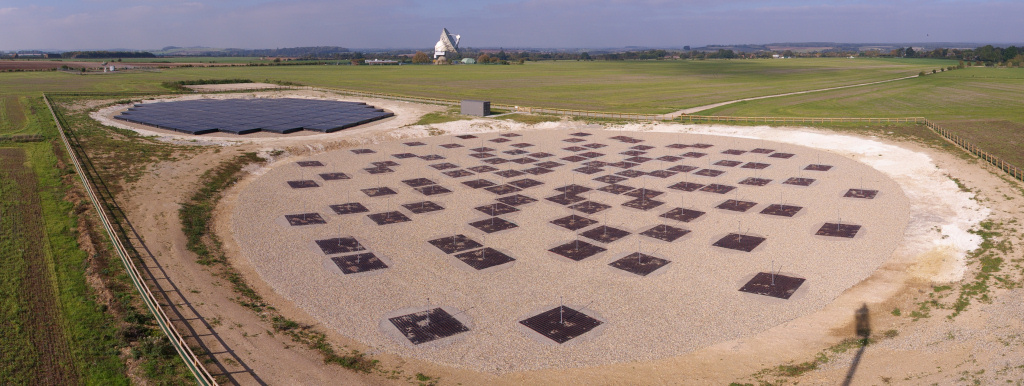

In [12]:
Image(filename='figures/arrays/lofar_uk_station.jpg')

**图 1.11.10**：位于英国 Chilbolton 天文台的 LOFAR-UK 国际台站。左上角黑色平面结构是高频阵（HBA），由 96 块 tile 组成，每块包含 16 个蝴蝶形双偏振偶极子；前景中的方形区域是低频阵（LBA），由 96 个双偏振下垂式偶极子构成。台站的电子定向设备位于中央灰色小房中。图片来源： [LOFAR-UK/D. McKay-Bukowski&#10548;](http://www.lofar-uk.org/images/view_123b.jpg)


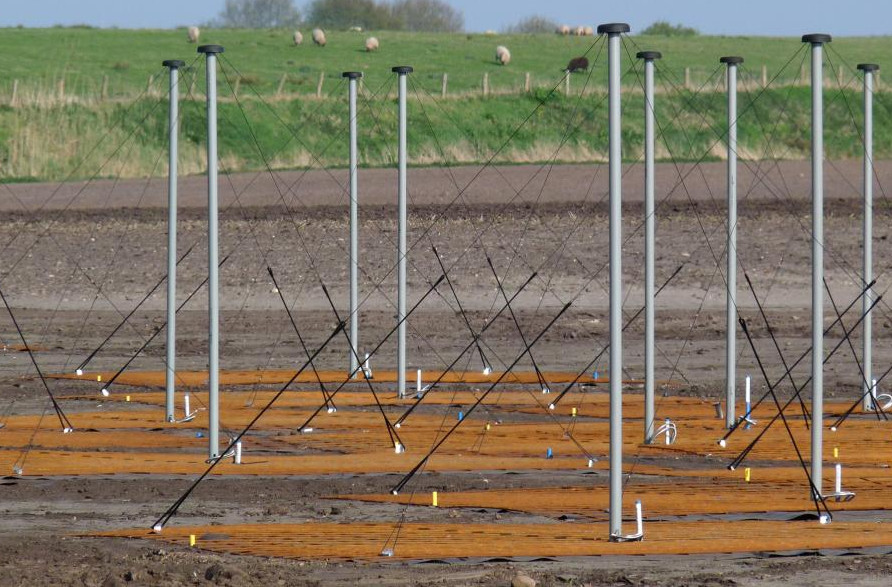

In [13]:
Image(filename='figures/arrays/lofar_lba_element.jpg')

**图 1.11.11**：LOFAR 低频阵（LBA）的下垂式偶极子阵元。它们组合成孔径阵，从而作为一台可电子转向的望远镜工作。图片来源： [ASTRON&#10548;](https://www.astron.nl/sites/astron.nl/files/cms/LOFAR%20LBA%20cs302.jpg)


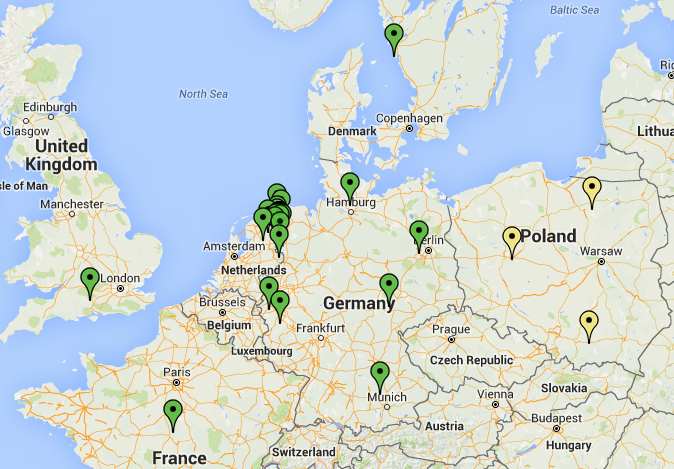

In [14]:
Image(filename='figures/arrays/lofar_station_map_oct_2015.png')

**图 1.11.12**：截至 2015 年 10 月的 LOFAR 台站分布示意图。核心区和 superterp 位于荷兰 Exloo 附近。图片来源：ASTRON/George Heald。最新的交互式阵列地图可见 [此处](https://www.astron.nl/lofartools/lofarmap.html)。


低频孔径阵在科学上打开了传统碟阵难以覆盖的观测窗口，但也把数据处理难度显著提高。由于视场极大，天空中大量离轴源都会参与成像；由于工作在低频，电离层相位扰动会非常显著；由于波束是数字合成的，方向依赖效应与频率依赖效应也更强。这正是为什么 LOFAR 等低频阵会推动方向依赖校准、宽场成像和大规模计算方法迅速发展。阵列类型一旦改变，后端算法就不再只是附属品，而会成为望远镜能力的一部分。


### 1.11.5 毫米和亚毫米干涉阵：把问题推向高频端

如果说低频阵把问题推向了长波长，那么 ALMA 则把射电干涉测量推进到了毫米和亚毫米高频端。在这个频率范围，天线表面精度、大气水汽、相位稳定性和站址海拔都变得极其关键。许多在 cm 波段看似“理所当然”的事情，在高频上都必须重新仔细处理。


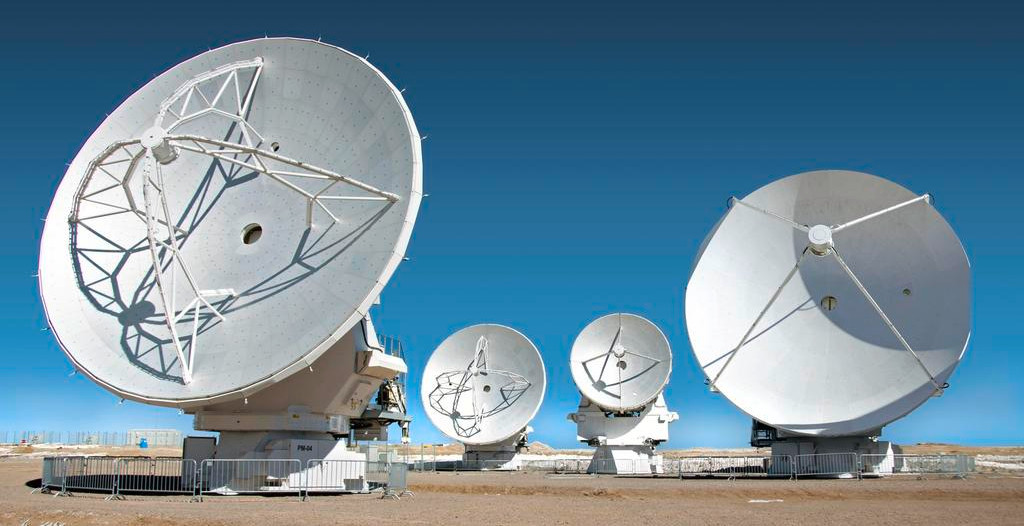

In [15]:
Image(filename='figures/arrays/alma_dishes.jpg')

**图 1.11.13**：ALMA 的四种天线类型，包括欧洲、北美和日本提供的 12 米口径天线，以及 7 米口径天线。图片来源： [ALMA (ESO/NAOJ/NRAO), W. Garnier (ALMA)&#10548;](http://www.almaobservatory.org/en/visuals/images/?g2_itemId=3933)


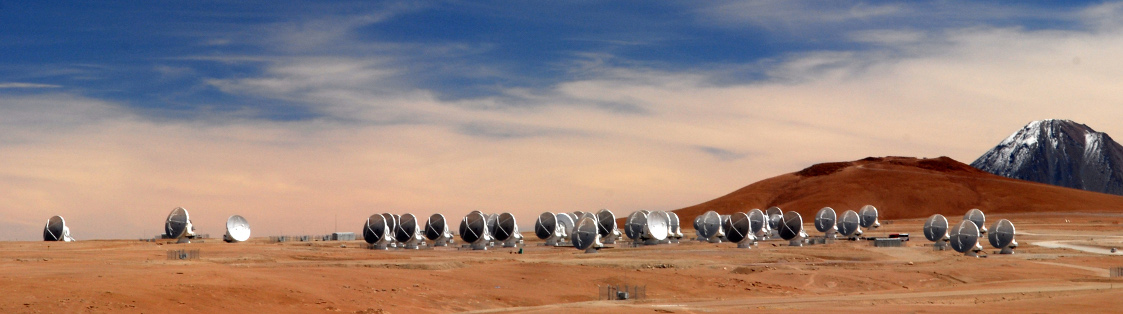

In [16]:
Image(filename='figures/arrays/alma_core_layout.jpg')

**图 1.11.14**：位于智利 Chajnantor 高原上的 ALMA 核心区布局，由 12 m 和 7 m 天线组成，其中部分天线可重新部署，以改变可见度采样方式，这一点与 VLA 类似。图片来源： [ALMA (ESO/NAOJ/NRAO), O. Dessibourg&#10548;](http://almaobservatory.org/gallery2/main.php?g2_view=core.DownloadItem&g2_itemId=4583)


ALMA 的价值在于，它把“阵列设计服务科学目标”这句话体现得非常充分。毫米和亚毫米观测高度重视冷分子气体、尘埃连续谱、化学组成和高角分辨率下的原行星盘结构，因此既需要较高频率带来的本征高分辨率，也需要良好的谱线能力和对扩展结构的恢复能力。也正因此，短间距补偿、7 m 阵列与总功率数据的配合，在 ALMA 语境下尤为重要。这一点说明，干涉阵从来不是“分辨率越高越好”，而是必须同时考虑不同空间尺度的信息恢复。


### 1.11.6 全球网络与极长基线：VLBI

还有一种思路不是重新建造一台阵列，而是把已经存在、相距极远的望远镜临时组织成网络，这就是 VLBI。它的目标不是大视场或高巡天速度，而是把角分辨率推到极限。由于基线尺度可达大陆乃至地球尺度，VLBI 能够解析喷流核心、致密吸积结构以及超高亮温区域，是研究活动星系核和精密天体测量的核心手段。


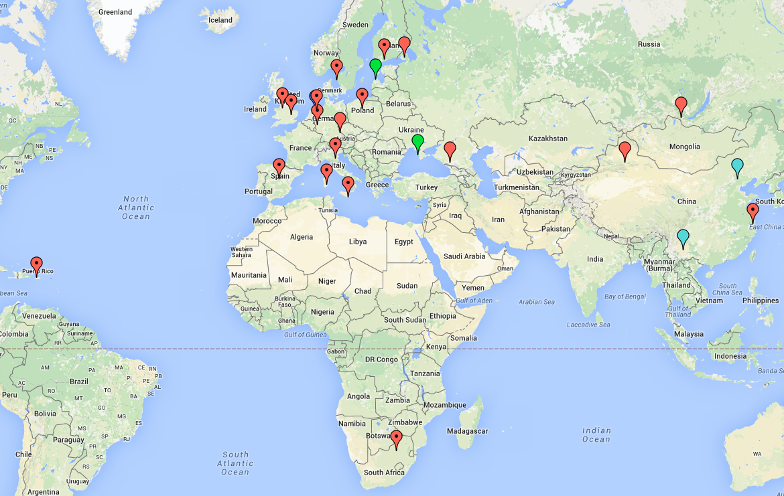

In [17]:
Image(filename='figures/arrays/evn_map.png')

**图 1.11.15**：欧洲 VLBI 网络中的望远镜分布。图片来源： [EVN&#10548;](https://www.evlbi.org/telescopes)


VLBI 同时也提醒我们，干涉测量并不只是“把天线放远一点”。当基线极长时，时间同步、频率标准、地球定向参数、站位精度、延迟模型和后相关处理都会变得极其关键。也就是说，VLBI 把许多在普通阵列里隐藏在后台的问题，直接推到了科学分析的前台。因此它特别适合作为后续高级实践和误差传播教学的案例。


### 1.11.7 实验驱动阵列：EoR 与强度映射

并非所有干涉阵都追求“成一张漂亮图像”。有些实验更关心统计信号本身，例如宇宙再电离时期 21 cm 功率谱，或者大尺度结构中的 H I 强度映射。此时阵列设计会更强调冗余基线、系统稳定性、宽视场和大尺度统计测量，而不一定以传统高保真成像为首要目标。


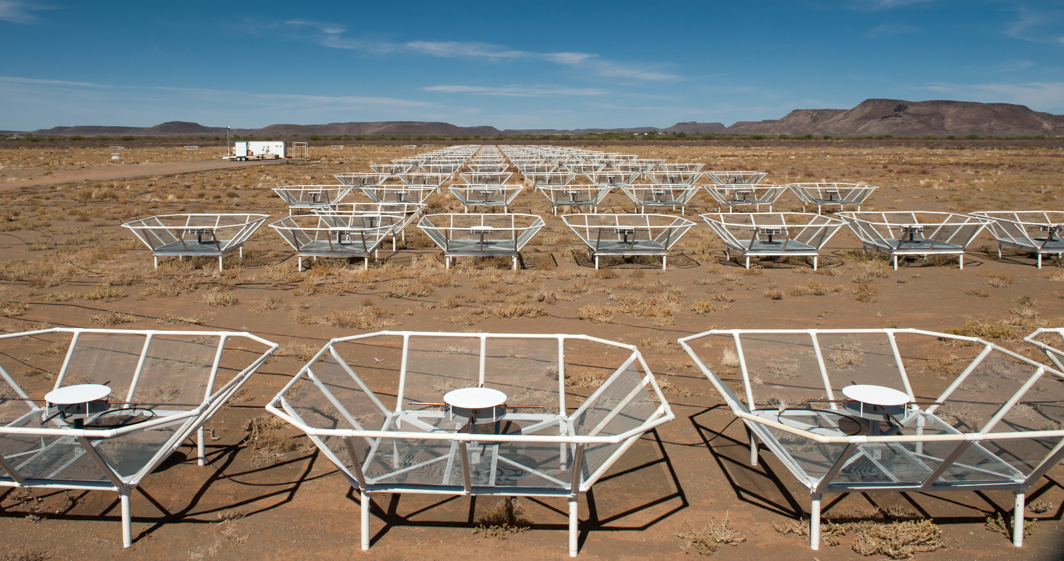

In [18]:
Image(filename='figures/arrays/paper_2013.jpg')

**图 1.11.16**：位于南非北开普的 PAPER 再电离时期实验阵列，采用带有网状反射面的双偏振偶极子阵元。图片来源： [SARAO&#10548;](https://www.sarao.ac.za/science/paper/)


In [ ]:
Image(filename='figures/arrays/chime_array.jpg')

**图 1.11.17**：位于加拿大 Penticton 附近的 CHIME BAO 强度映射阵列。四个圆柱面反射器的信号经过数字波束形成与相关处理。该阵列工作在 400 MHz 到 800 MHz，对应 21 cm 谱线的红移范围约为 2.5 到 0.8。图片来源： [Canadian Astronomical Society&#10548;](http://casca.ca/wp-content/uploads/2015/09/Figure1Chime.jpg)


这类阵列说明，“干涉测量”并不等于“常规成像”。PAPER 这类再电离实验阵列更强调冗余标定和功率谱估计；CHIME 这类强度映射阵列则展示了漂移扫描、圆柱反射面和大规模数字后端如何服务于宇宙学统计研究。科学问题一旦改变，阵列设计目标、定标策略和最终数据产品都可能跟着改变。


### 1.11.8 SKA 代表什么

SKA 更适合被理解为一种方向，而不只是某一台具体设施。它综合了过去几十年射电阵列发展中最重要的几条路线：低频孔径阵、中频高性能碟阵、超大数据率后端、以及围绕长期国际协作形成的软件与计算基础设施。也正因此，学习 MeerKAT、ASKAP、LOFAR、ALMA 和 VLBI，并不是在记若干互不相关的设施，而是在理解通往下一代阵列的不同技术分支。

SKA 的真正启发在于：未来射电干涉测量的瓶颈未必只在硬件，也可能在数据传输、校准、成像算法、计算资源和团队协作方式上。现代阵列越强大，越需要把“望远镜”理解为硬件、软件和工作流共同组成的整体系统。


### 1.11.9 本节小结

现代射电干涉阵的差异，本质上来自科学问题的差异。频率范围决定主要科学对象，也决定大气、电离层和硬件设计难点；阵元类型决定视场、波束控制方式和校准复杂度；基线分布决定角分辨率与最大可恢复尺度之间的权衡；宽带、多波束、偏振和高频能力会显著改变后端处理工作量。

至此，第 1 章完成了从射电科学背景、辐射机制与射电源，到单碟局限和现代阵列类型的整体铺垫。后续章节将不再停留在现象与设施层面，而会进入干涉测量真正的方法主线：坐标、几何、可见度、成像、定标和实践。


***

* 下一节： [1.12 延伸阅读与参考文献](1_x_further_reading_and_references.ipynb)
